In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
df = pd.read_csv('df_train.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(["symbol", "date"])

,date,symbol,open,close,low,high,volume
0,2010-01-04,ACTS,15.13,14.97,14.84,15.28,5459.882
100,2010-01-05,ACTS,15.16,14.85,14.75,15.30,4023.304
200,2010-01-06,ACTS,14.92,14.86,14.49,15.31,5210.519
300,2010-01-07,ACTS,15.02,14.70,14.65,15.13,4070.668
400,2010-01-08,ACTS,14.53,14.40,14.16,14.86,31661.674
...,...,...,...,...,...,...,...
100199,2013-12-24,ZQN,20.20,20.13,19.83,20.27,65078.723
100299,2013-12-26,ZQN,19.72,20.11,19.50,20.36,100317.903
100399,2013-12-27,ZQN,20.88,20.90,20.58,20.95,97726.404
100499,2013-12-30,ZQN,20.86,20.81,20.58,21.11,77924.946


Analysis

/tmp/ipykernel_683/3998780901.py:15: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


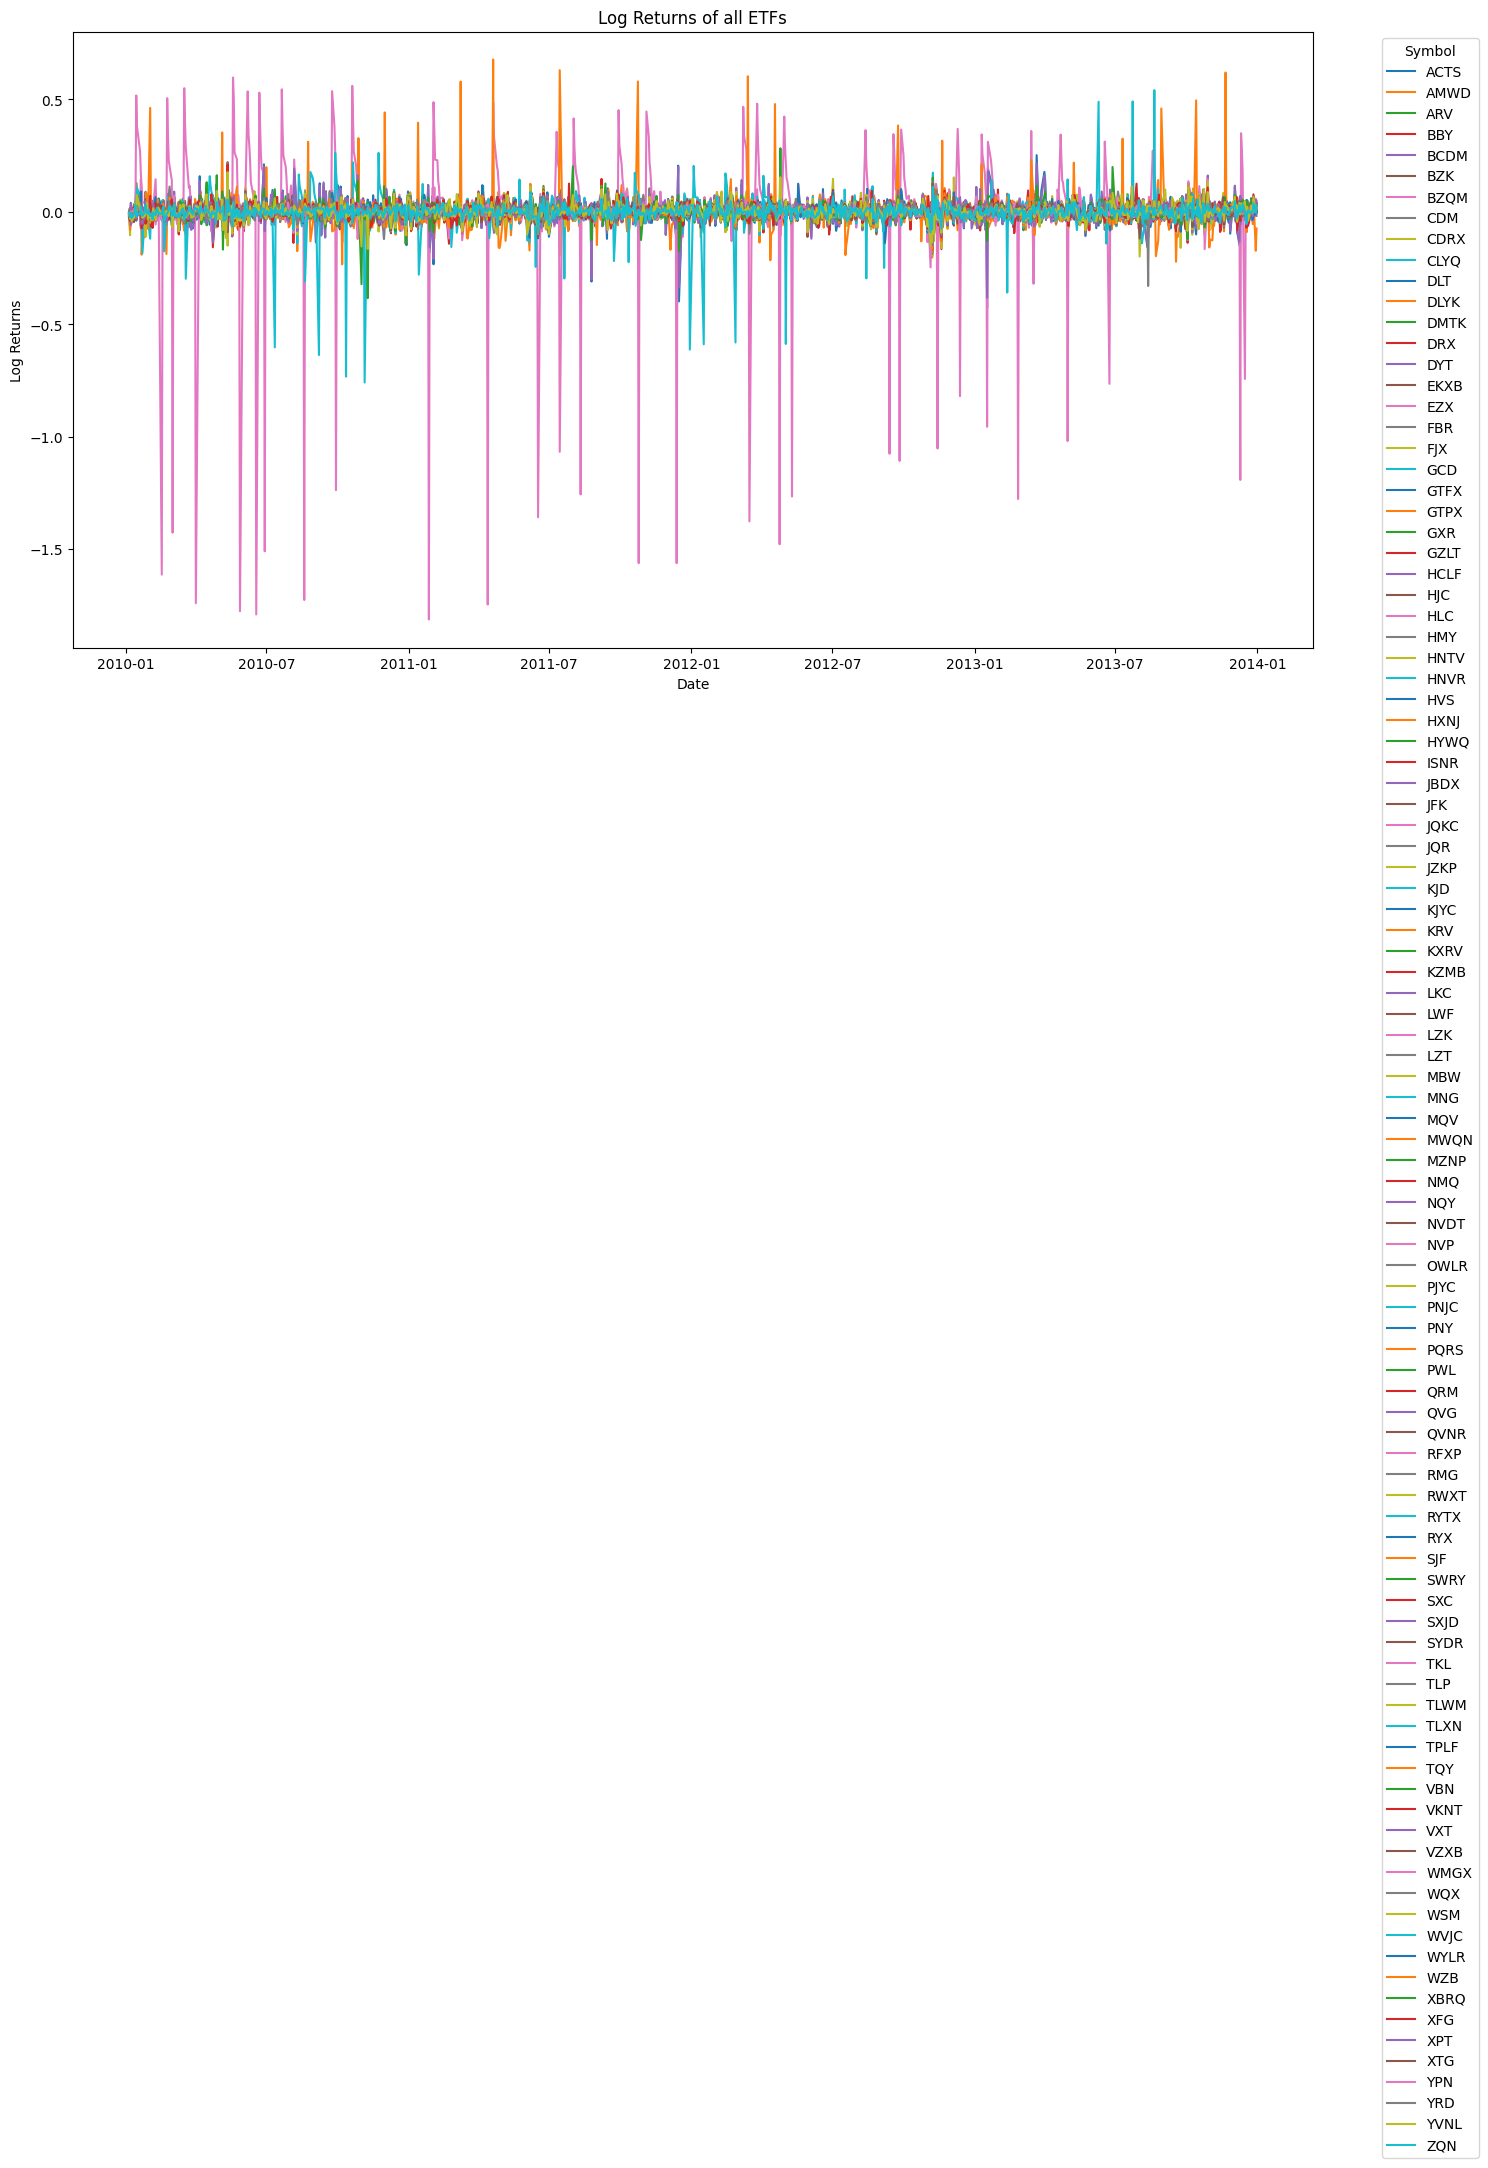

In [16]:
# daily log returns of all ETFs
df["log_return"] = df.groupby("symbol")["close"].transform(
    lambda x: np.log(x / x.shift(1))
)
returns = df.dropna(subset=["log_return"])

plt.figure(figsize=(16, 8))
for symbol in returns['symbol'].unique():
    symbol_returns = returns[returns['symbol'] == symbol]
    plt.plot(symbol_returns['date'], symbol_returns['log_return'], label=symbol)

plt.title('Log Returns of all ETFs')
plt.xlabel('Date')
plt.ylabel('Log Returns')
plt.legend(title='Symbol', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [22]:
# Find outlier events
threshold = 0.3
outlier_events = returns[returns['log_return'].abs() > threshold][['date', 'symbol', 'log_return']]

# Check if outliers are on specific dates
print("outliers by dates")
print(outlier_events.groupby('date').size().sort_values(ascending=False).head(20))

# Check if outliers are from specific stocks
print("\noutliers by symbols")
print(outlier_events.groupby('symbol').size().sort_values(ascending=False).head(20))

# Check if a spike in one direction predicts a reversal next day
outlier_events['next_day_return'] = outlier_events.apply(
    lambda row: returns[(returns['symbol'] == row['symbol']) &
                        (returns['date'] > row['date'])]['log_return'].iloc[0]
    if len(returns[(returns['symbol'] == row['symbol']) &
                   (returns['date'] > row['date'])]) > 0 else np.nan, axis=1
)
print("\nreversal prediction")
print(outlier_events[['log_return', 'next_day_return']].corr())

outliers by dates
date
2013-01-17    3
2011-07-15    2
2011-08-25    2
2011-04-20    2
2011-12-16    2
2010-01-15    1
2010-02-01    1
2010-02-16    1
2010-01-14    1
2010-04-01    1
2010-05-05    1
2010-05-19    1
2010-05-20    1
2010-05-28    1
2010-06-07    1
2010-06-08    1
2010-06-18    1
2010-06-22    1
2010-06-23    1
2010-06-29    1
dtype: int64

outliers by symbols
symbol
LZK     71
PQRS    18
RYTX    13
DLT      3
QVG      3
XBRQ     2
YRD      1
dtype: int64

reversal prediction
                 log_return  next_day_return
log_return         1.000000         0.469324
next_day_return    0.469324         1.000000


In [23]:
# Verify the momentum signal more carefully on just the 3 signal ETFs
signal_etfs = ['LZK', 'PQRS', 'RYTX']
signal_returns = returns[returns['symbol'].isin(signal_etfs)].copy()

# Check autocorrelation at lags 1, 2, 3 days
for etf in signal_etfs:
    etf_data = signal_returns[signal_returns['symbol'] == etf]['log_return']
    for lag in [1, 2, 3]:
        corr = etf_data.autocorr(lag=lag)
        print(f"{etf} lag-{lag} autocorr: {corr:.4f}")

# Check if the momentum effect holds on SMALL moves too, or only big ones
signal_returns['prev_return'] = signal_returns.groupby('symbol')['log_return'].shift(1)
signal_returns['move_size'] = pd.cut(
    signal_returns['prev_return'].abs(),
    bins=[0, 0.05, 0.1, 0.3, np.inf],
    labels=['tiny', 'small', 'medium', 'large']
)
print(signal_returns.groupby('move_size', observed=True)[['prev_return', 'log_return']].corr())

LZK lag-1 autocorr: 0.0708
LZK lag-2 autocorr: 0.0130
LZK lag-3 autocorr: -0.0274
PQRS lag-1 autocorr: 0.0390
PQRS lag-2 autocorr: -0.0032
PQRS lag-3 autocorr: -0.0122
RYTX lag-1 autocorr: 0.1113
RYTX lag-2 autocorr: 0.0355
RYTX lag-3 autocorr: 0.0043
                       prev_return  log_return
move_size                                     
tiny      prev_return     1.000000   -0.028732
          log_return     -0.028732    1.000000
small     prev_return     1.000000   -0.004298
          log_return     -0.004298    1.000000
medium    prev_return     1.000000    0.177685
          log_return      0.177685    1.000000
large     prev_return     1.000000    0.475741
          log_return      0.475741    1.000000


              sum          mean  count
symbol                                
LZK     10.886030  1.083187e-02   1005
PQRS     0.003063  3.047811e-06   1005
RYTX    -0.000828 -8.234948e-07   1005

Total strategy PnL: 10.888265253029441
Win rate: 0.7156862745098039


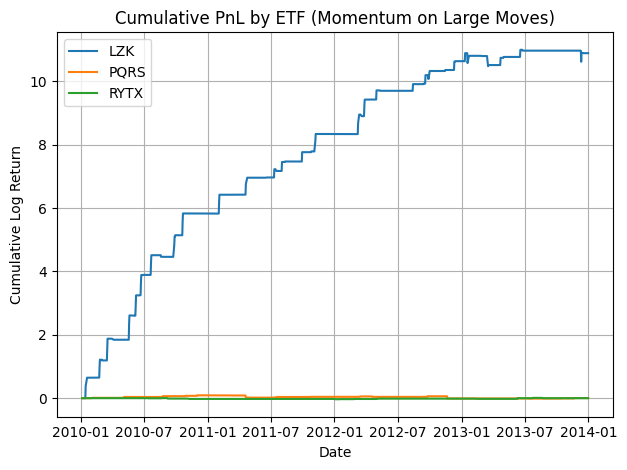

In [24]:
# Simulate the simple strategy to validate PnL
signal_etfs = ['LZK', 'PQRS', 'RYTX']
threshold = 0.3  # only trade on large moves

signal_df = returns[returns['symbol'].isin(signal_etfs)].copy().sort_values(['symbol','date'])
signal_df['prev_return'] = signal_df.groupby('symbol')['log_return'].shift(1)

# Signal: if yesterday's move was large, bet on continuation
signal_df['position'] = np.where(signal_df['prev_return'] > threshold, 1,
                        np.where(signal_df['prev_return'] < -threshold, -1, 0))

# PnL = position * next day return (minus 5bps transaction cost)
signal_df['trade_made'] = signal_df['position'] != signal_df.groupby('symbol')['position'].shift(1).fillna(0)
signal_df['pnl'] = signal_df['position'] * signal_df['log_return'] - 0.0005 * signal_df['trade_made']

# Summarise
print(signal_df.groupby('symbol')['pnl'].agg(['sum','mean','count']))
print("\nTotal strategy PnL:", signal_df['pnl'].sum())
print("Win rate:", (signal_df[signal_df['position']!=0]['pnl'] > 0).mean())

# Plot cumulative PnL
signal_df_sorted = signal_df.sort_values('date')
signal_df_sorted['cum_pnl'] = signal_df_sorted.groupby('symbol')['pnl'].cumsum()

import matplotlib.pyplot as plt
for etf in signal_etfs:
    etf_data = signal_df_sorted[signal_df_sorted['symbol'] == etf]
    plt.plot(etf_data['date'], etf_data['cum_pnl'], label=etf)

plt.title('Cumulative PnL by ETF (Momentum on Large Moves)')
plt.xlabel('Date')
plt.ylabel('Cumulative Log Return')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# Test different thresholds to find the most robust one
results = []
for thresh in [0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5]:
    df_t = signal_df.copy()
    df_t['position'] = np.where(df_t['prev_return'] > thresh, 1,
                       np.where(df_t['prev_return'] < -thresh, -1, 0))
    df_t['trade_made'] = df_t['position'] != df_t.groupby('symbol')['position'].shift(1).fillna(0)
    df_t['pnl'] = df_t['position'] * df_t['log_return'] - 0.0005 * df_t['trade_made']
    results.append({'threshold': thresh, 'total_pnl': df_t['pnl'].sum(),
                    'n_trades': df_t['trade_made'].sum()})

print(pd.DataFrame(results))

   threshold  total_pnl  n_trades
0       0.10  17.706735       301
1       0.15  16.596710       247
2       0.20  16.889514       210
3       0.25  13.328968       186
4       0.30  10.888265       173
5       0.40   5.998887       134
6       0.50   2.853925       104


Lower thresholds = more trades = more PnL. This tells you the momentum signal isn't exclusive to extreme moves — it exists at moderate move sizes too (10–20%). However, be careful about naively picking 0.10 just because it maximises in-sample PnL. The risk is overfitting — a lower threshold means more trades on noisier signals that may not persist in the test data.

In [26]:
signal_df['year'] = signal_df['date'].dt.year
print(signal_df[signal_df['symbol']=='LZK'].groupby('year')['pnl'].sum())

year
2010    5.828105
2011    2.504636
2012    2.301038
2013    0.252252
Name: pnl, dtype: float64


In [27]:
# Check how many large moves LZK had per year
lzk = returns[returns['symbol'] == 'LZK'].copy()
lzk['year'] = lzk['date'].dt.year
lzk['is_large'] = lzk['log_return'].abs() > 0.3

# Is it fewer signals, or weaker continuation when signals occur?
print("Large moves per year:")
print(lzk.groupby('year')['is_large'].sum())

print("\nMean next-day return after large move, by year:")
lzk['prev_large'] = lzk['is_large'].shift(1)
lzk['prev_return'] = lzk['log_return'].shift(1)
lzk_signal = lzk[lzk['prev_large'] == True]
print(lzk_signal.groupby('year').apply(
    lambda x: (x['log_return'] * np.sign(x['prev_return'])).mean()
))

Large moves per year:
year
2010    26
2011    16
2012    16
2013    13
Name: is_large, dtype: int64

Mean next-day return after large move, by year:
year
2010    0.224812
2011    0.157352
2012    0.144690
2013    0.020289
dtype: float64


/tmp/ipykernel_683/1942294145.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(lzk_signal.groupby('year').apply(


/tmp/ipykernel_683/3163695088.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lzk_signal['date'] = pd.to_datetime(lzk_signal['date'])


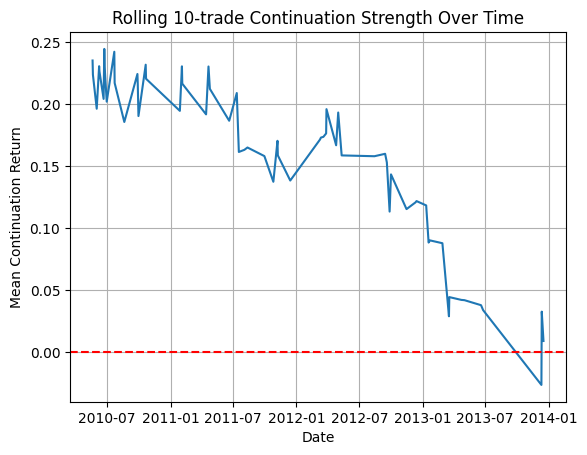

Threshold 0.1: {2010: 4.754717347397341, 2011: 4.208645239748105, 2012: 2.874438964524549, 2013: 0.7608394239946019}
Threshold 0.2: {2010: 6.813712284326176, 2011: 4.378821682865725, 2012: 3.5374492466393677, 2013: 1.2656626928207817}
Threshold 0.3: {2010: 5.8281045505300835, 2011: 2.504635864972187, 2012: 2.301037612386128, 2013: 0.25225178697150963}


In [28]:
# 1. Check if the signal decay is gradual or a sudden structural break
lzk_signal['date'] = pd.to_datetime(lzk_signal['date'])
lzk_signal = lzk_signal.sort_values('date')
lzk_signal['rolling_continuation'] = (
    lzk_signal['log_return'] * np.sign(lzk_signal['prev_return'])
).rolling(window=10).mean()

plt.plot(lzk_signal['date'], lzk_signal['rolling_continuation'])
plt.axhline(0, linestyle='--', color='red')
plt.title('Rolling 10-trade Continuation Strength Over Time')
plt.xlabel('Date')
plt.ylabel('Mean Continuation Return')
plt.grid(True)
plt.show()

# 2. Check if a lower threshold rescues the 2013 signal
for thresh in [0.1, 0.2, 0.3]:
    lzk2 = returns[returns['symbol'] == 'LZK'].copy()
    lzk2['year'] = lzk2['date'].dt.year
    lzk2['prev_return'] = lzk2['log_return'].shift(1)
    lzk2['position'] = np.where(lzk2['prev_return'] > thresh, 1,
                       np.where(lzk2['prev_return'] < -thresh, -1, 0))
    lzk2['pnl'] = lzk2['position'] * lzk2['log_return'] - 0.0005 * (lzk2['position'] != lzk2['position'].shift(1).fillna(0))
    print(f"Threshold {thresh}:", lzk2.groupby('year')['pnl'].sum().to_dict())

attempting alternative signal

=== Combined Strategy PnL ===
By ETF: {'LZK': 15.99564590665205, 'PQRS': 2.346351861584363, 'RYTX': 1.3608712467952966}

By Year:
year
2010    8.083190
2011    5.178489
2012    3.949220
2013    2.491970
Name: pnl, dtype: float64

Total: 19.70286901503171


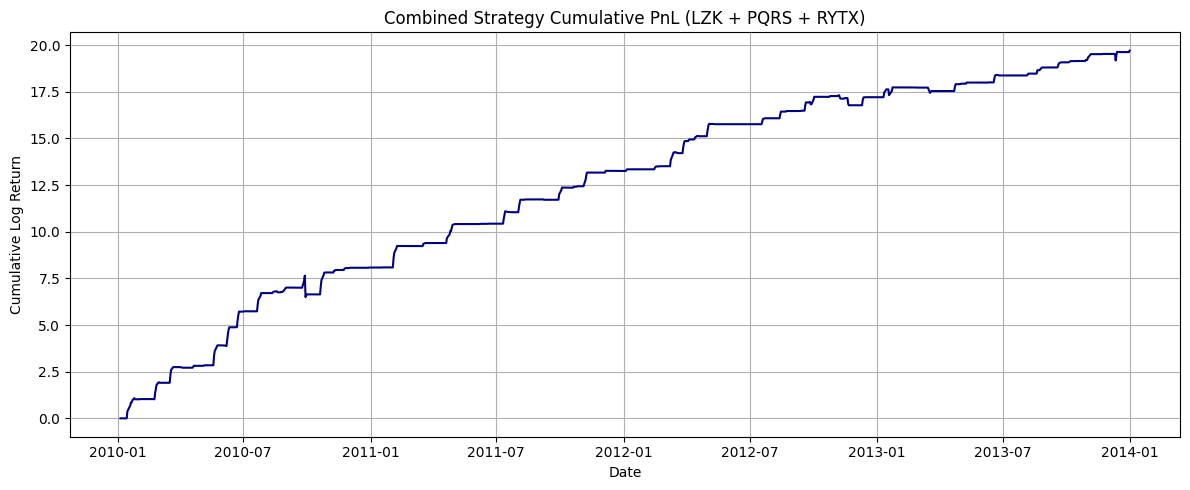

In [29]:
# Combined strategy: LZK + PQRS momentum, small RYTX allocation
import pandas as pd
import numpy as np

df = pd.read_csv('df_train.csv', parse_dates=['date'])
df = df.sort_values(['symbol','date'])
df['log_return'] = df.groupby('symbol')['close'].transform(lambda x: np.log(x/x.shift(1)))
returns = df.dropna(subset=['log_return'])

# Parameters
configs = {
    'LZK':  {'threshold': 0.2, 'size': 1.0},   # primary - but fading
    'PQRS': {'threshold': 0.1, 'size': 1.0},   # secondary - stable/growing
    'RYTX': {'threshold': 0.1, 'size': 0.5},   # tertiary - noisy, half size
}

all_pnl = []
for etf, cfg in configs.items():
    r = returns[returns['symbol'] == etf].copy().sort_values('date')
    r['prev_return'] = r['log_return'].shift(1)
    r['position'] = np.where(r['prev_return'] >  cfg['threshold'],  cfg['size'],
                    np.where(r['prev_return'] < -cfg['threshold'], -cfg['size'], 0))
    r['trade_made'] = r['position'] != r['position'].shift(1).fillna(0)
    r['pnl'] = r['position'] * r['log_return'] - 0.0005 * r['trade_made']
    r['year'] = r['date'].dt.year
    all_pnl.append(r[['date','year','symbol','pnl']])

combined = pd.concat(all_pnl)

# Total and by year
print("=== Combined Strategy PnL ===")
print("By ETF:", combined.groupby('symbol')['pnl'].sum().to_dict())
print("\nBy Year:")
print(combined.groupby('year')['pnl'].sum())
print("\nTotal:", combined['pnl'].sum())

# Plot combined cumulative PnL
import matplotlib.pyplot as plt
combined_daily = combined.groupby('date')['pnl'].sum().cumsum()
plt.figure(figsize=(12,5))
plt.plot(combined_daily.index, combined_daily.values, color='navy', linewidth=1.5)
plt.title('Combined Strategy Cumulative PnL (LZK + PQRS + RYTX)')
plt.xlabel('Date')
plt.ylabel('Cumulative Log Return')
plt.grid(True)
plt.tight_layout()
plt.show()

exploring other signals

In [30]:
import pandas as pd
import numpy as np
from scipy import stats

# ── Load data ────────────────────────────────────────────────────────────────
df = pd.read_csv('df_train.csv', parse_dates=['date'])
df = df.sort_values(['symbol', 'date'])
df['log_return'] = df.groupby('symbol')['close'].transform(lambda x: np.log(x / x.shift(1)))
df['intraday'] = df['close'] - df['open']
df['overnight'] = df.groupby('symbol')['open'].transform(lambda x: x - x.shift(1))
df['range'] = (df['high'] - df['low']) / df['close']
df['volume_z'] = df.groupby('symbol')['volume'].transform(
    lambda x: (x - x.rolling(20).mean()) / x.rolling(20).std()
)
returns = df.dropna(subset=['log_return'])


# ════════════════════════════════════════════════════════════════════════════
# SIGNAL 1: Intraday direction → next day return
# Question: does the direction of today's open→close move predict tomorrow?
# Positive correlation = intraday momentum carries over
# Negative correlation = intraday move reverses next day
# ════════════════════════════════════════════════════════════════════════════
signal1 = []
for symbol, grp in returns.groupby('symbol'):
    grp = grp.sort_values('date')
    intra_sign = np.sign(grp['intraday'].values[:-1])
    next_r = grp['log_return'].values[1:]
    corr = np.corrcoef(intra_sign, next_r)[0, 1]
    signal1.append({'symbol': symbol, 'intraday_pred': corr})

signal1_df = pd.DataFrame(signal1).sort_values('intraday_pred', key=abs, ascending=False)
print("=== SIGNAL 1: Intraday Direction -> Next Day Return ===")
print("Positive = momentum, Negative = reversal")
print(signal1_df.head(20).to_string(index=False))


# ════════════════════════════════════════════════════════════════════════════
# SIGNAL 2: Volume spike → next day direction
# Question: after unusually high volume (z-score > 1.5), does price continue
#           or reverse the next day?
# Positive = continuation after volume spike
# Negative = reversal after volume spike (most common in real markets)
# ════════════════════════════════════════════════════════════════════════════
signal2 = []
for symbol, grp in returns.groupby('symbol'):
    grp = grp.sort_values('date')
    vol_z = grp['volume_z'].values
    r = grp['log_return'].values
    high_vol_mask = vol_z[:-1] > 1.5
    if high_vol_mask.sum() > 5:
        corr = np.corrcoef(r[:-1][high_vol_mask], r[1:][high_vol_mask])[0, 1]
        n = high_vol_mask.sum()
    else:
        corr, n = np.nan, 0
    signal2.append({'symbol': symbol, 'volume_direction': corr, 'n_vol_spikes': n})

signal2_df = pd.DataFrame(signal2).dropna().sort_values('volume_direction', key=abs, ascending=False)
print("\n=== SIGNAL 2: Volume Spike -> Next Day Direction ===")
print("Positive = continuation, Negative = reversal after high volume")
print(signal2_df.head(20).to_string(index=False))


# ════════════════════════════════════════════════════════════════════════════
# SIGNAL 3: 5-day momentum → next day return
# Question: does a 5-day trend predict where tomorrow goes?
# Positive = trend continues (momentum)
# Negative = trend reverses (mean reversion) — dominant signal found here
# ════════════════════════════════════════════════════════════════════════════
signal3 = []
for symbol, grp in returns.groupby('symbol'):
    grp = grp.sort_values('date')
    r = grp['log_return'].values
    ret_5d = pd.Series(r).rolling(5).sum().shift(1).values
    valid = ~np.isnan(ret_5d)
    corr = np.corrcoef(ret_5d[valid], r[valid])[0, 1] if valid.sum() > 10 else np.nan
    signal3.append({'symbol': symbol, 'momentum_5d': corr})

signal3_df = pd.DataFrame(signal3).dropna().sort_values('momentum_5d', key=abs, ascending=False)
print("\n=== SIGNAL 3: 5-Day Momentum -> Next Day Return ===")
print("Positive = momentum, Negative = mean reversion after 5-day trend")
print(signal3_df.head(20).to_string(index=False))


# ════════════════════════════════════════════════════════════════════════════
# SIGNAL 4: Overnight gap → next day return
# Question: does the gap between yesterday's close and today's open
#           predict today's close-to-close return?
# Positive = gap predicts continuation
# Negative = gap predicts reversal (gap fill)
# ════════════════════════════════════════════════════════════════════════════
signal4 = []
for symbol, grp in returns.groupby('symbol'):
    grp = grp.sort_values('date')
    overnight = grp['overnight'].values
    r = grp['log_return'].values
    corr = np.corrcoef(overnight[:-1], r[1:])[0, 1] if len(overnight) > 10 else np.nan
    signal4.append({'symbol': symbol, 'overnight_pred': corr})

signal4_df = pd.DataFrame(signal4).dropna().sort_values('overnight_pred', key=abs, ascending=False)
print("\n=== SIGNAL 4: Overnight Gap -> Next Day Return ===")
print("Positive = gap continues, Negative = gap fills/reverses")
print(signal4_df.head(20).to_string(index=False))


# ════════════════════════════════════════════════════════════════════════════
# COMBINED SUMMARY — top candidates across all signals
# ════════════════════════════════════════════════════════════════════════════
all_signals = (signal1_df.set_index('symbol')
               .join(signal2_df.set_index('symbol')[['volume_direction']])
               .join(signal3_df.set_index('symbol')[['momentum_5d']])
               .join(signal4_df.set_index('symbol')[['overnight_pred']]))

# ETFs that appear strongly in multiple signals are most robust
all_signals['n_strong_signals'] = (
    (all_signals['intraday_pred'].abs() > 0.05).astype(int) +
    (all_signals['volume_direction'].abs() > 0.25).astype(int) +
    (all_signals['momentum_5d'].abs() > 0.08).astype(int) +
    (all_signals['overnight_pred'].abs() > 0.05).astype(int)
)
print("\n=== MULTI-SIGNAL ETFs (most robust candidates) ===")
print(all_signals[all_signals['n_strong_signals'] >= 2]
      .sort_values('n_strong_signals', ascending=False).to_string())

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


=== SIGNAL 1: Intraday Direction -> Next Day Return ===
Positive = momentum, Negative = reversal
symbol  intraday_pred
   XTG      -0.102230
   LZK      -0.098643
   FJX      -0.083361
  PQRS      -0.066775
  RYTX      -0.065015
  TLWM      -0.053717
   XFG       0.053163
  CLYQ       0.050990
  CDRX      -0.050904
  XBRQ      -0.050864
  HNVR       0.048877
  TLXN       0.048646
   DYT       0.048396
   NMQ       0.047625
   SXC       0.047008
   FBR      -0.045865
  DLYK       0.045328
  SXJD       0.044988
  MZNP       0.041615
   RYX      -0.041069

=== SIGNAL 2: Volume Spike -> Next Day Direction ===
Positive = continuation, Negative = reversal after high volume
symbol  volume_direction  n_vol_spikes
   TKL         -0.391090            91
  HNVR          0.334848            94
   BBY         -0.330096            94
   CDM         -0.322985           106
  EKXB         -0.313225            90
   MBW         -0.311060            99
  ACTS         -0.292527            95
  JZKP      

In [31]:
# Test: what does 5-day mean reversion look like applied to ALL 97 non-signal ETFs?
signal_etfs = ['LZK', 'PQRS', 'RYTX']
broad_universe = returns[~returns['symbol'].isin(signal_etfs)].copy()

broad_universe['ret_5d'] = broad_universe.groupby('symbol')['log_return'].transform(
    lambda x: x.rolling(5).sum().shift(1)
)
broad_universe['position'] = np.where(broad_universe['ret_5d'] >  0.05, -0.1,
                             np.where(broad_universe['ret_5d'] < -0.05,  0.1, 0))
broad_universe['trade_made'] = broad_universe.groupby('symbol')['position'].transform(
    lambda x: (x != x.shift(1).fillna(0)).astype(int)
)
broad_universe['pnl'] = (broad_universe['position'] * broad_universe['log_return']
                         - 0.0005 * broad_universe['trade_made'])

print("Broad universe mean reversion PnL by year:")
broad_universe['year'] = broad_universe['date'].dt.year
print(broad_universe.groupby('year')['pnl'].sum().round(3))
print("Total:", broad_universe['pnl'].sum().round(3))

Broad universe mean reversion PnL by year:
year
2010   -0.336
2011   -1.944
2012   -1.269
2013   -2.789
Name: pnl, dtype: float64
Total: -6.339


general approaches

/tmp/ipykernel_683/2156708355.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  returns = returns.groupby('date', group_keys=False).apply(cross_sectional_positions)


=== PnL by Year ===
year
2010   -9.2411
2011    3.1051
2012   -6.3009
2013   -5.4659
Name: pnl, dtype: float64

=== PnL by Year (Long vs Short side) ===
position      -1       0       1
year                            
2010     -4.0126 -0.9050 -4.3235
2011      2.3909 -0.9435  1.6578
2012     -2.3642 -0.9800 -2.9567
2013     -4.4540 -0.9825 -0.0294

Total PnL: -17.9028
Win rate (active days): 0.4989
Avg daily PnL: -0.017903
Sharpe (annualised): -1.1045


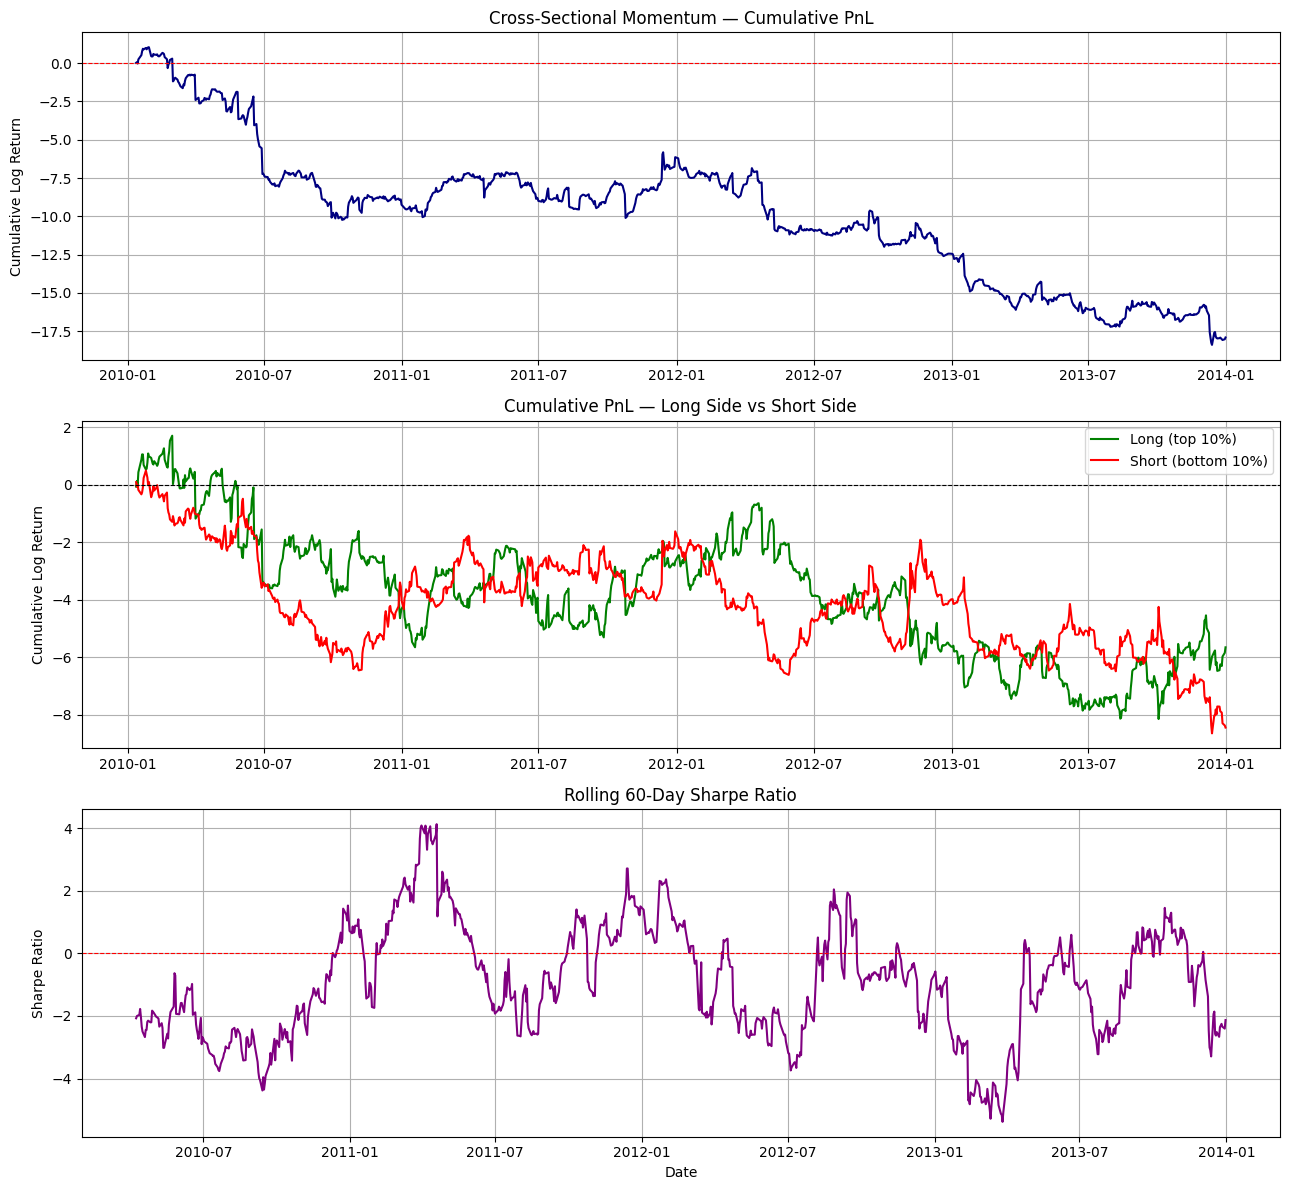

In [36]:
# cross sectional momentum
import pandas as pd
import numpy as np

df = pd.read_csv('df_train.csv', parse_dates=['date'])
df = df.sort_values(['symbol', 'date'])
df['log_return'] = df.groupby('symbol')['close'].transform(lambda x: np.log(x / x.shift(1)))
returns = df.dropna(subset=['log_return']).copy() # Added .copy() to prevent SettingWithCopyWarning

# ── Compute 5-day return and cross-sectional positions ───────────────────────
returns['ret_5d'] = returns.groupby('symbol')['log_return'].transform(
    lambda x: x.rolling(5).sum().shift(1)
)
returns = returns.dropna(subset=['ret_5d'])

def cross_sectional_positions(group):
    ranked = group['ret_5d'].rank(pct=True)
    group['position'] = np.where(ranked > 0.9,  1,
                        np.where(ranked < 0.1, -1, 0))
    return group

# Removed include_groups=False as it's not supported in this pandas version
returns = returns.groupby('date', group_keys=False).apply(cross_sectional_positions)

# ── Compute PnL ──────────────────────────────────────────────────────────────
# Transaction cost: 5bps on each trade (position change)
returns = returns.sort_values(['symbol', 'date'])
returns['prev_position'] = returns.groupby('symbol')['position'].shift(1).fillna(0)
returns['trade_made'] = (returns['position'] != returns['prev_position']).astype(int)
returns['pnl'] = returns['position'] * returns['log_return'] - 0.0005 * returns['trade_made']

# ── Summary stats ────────────────────────────────────────────────────────────
returns['year'] = returns['date'].dt.year

print("=== PnL by Year ===")
print(returns.groupby('year')['pnl'].sum().round(4))

print("\n=== PnL by Year (Long vs Short side) ===")
print(returns.groupby(['year', 'position'])['pnl'].sum().round(4).unstack())

print("\nTotal PnL:", returns['pnl'].sum().round(4))
print("Win rate (active days):", (returns[returns['position'] != 0]['pnl'] > 0).mean().round(4))
print("Avg daily PnL:", returns.groupby('date')['pnl'].sum().mean().round(6))
print("Sharpe (annualised):", (
    returns.groupby('date')['pnl'].sum().mean() /
    returns.groupby('date')['pnl'].sum().std() * np.sqrt(252)
).round(4))

# ── Plots ────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(13, 12))

# Plot 1: cumulative PnL overall
daily_pnl = returns.groupby('date')['pnl'].sum()
axes[0].plot(daily_pnl.index, daily_pnl.cumsum(), color='navy', linewidth=1.5)
axes[0].axhline(0, linestyle='--', color='red', linewidth=0.8)
axes[0].set_title('Cross-Sectional Momentum — Cumulative PnL')
axes[0].set_ylabel('Cumulative Log Return')
axes[0].grid(True)

# Plot 2: cumulative PnL split by long and short side
for side, label, color in [(1, 'Long (top 10%)', 'green'), (-1, 'Short (bottom 10%)', 'red')]:
    side_pnl = returns[returns['position'] == side].groupby('date')['pnl'].sum().cumsum()
    axes[1].plot(side_pnl.index, side_pnl.values, label=label, color=color, linewidth=1.5)
axes[1].axhline(0, linestyle='--', color='black', linewidth=0.8)
axes[1].set_title('Cumulative PnL — Long Side vs Short Side')
axes[1].set_ylabel('Cumulative Log Return')
axes[1].legend()
axes[1].grid(True)

# Plot 3: rolling 60-day Sharpe to see if strategy is stable over time
rolling_mean = daily_pnl.rolling(60).mean()
rolling_std  = daily_pnl.rolling(60).std()
rolling_sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
axes[2].plot(rolling_sharpe.index, rolling_sharpe.values, color='purple', linewidth=1.5)
axes[2].axhline(0, linestyle='--', color='red', linewidth=0.8)
axes[2].set_title('Rolling 60-Day Sharpe Ratio')
axes[2].set_ylabel('Sharpe Ratio')
axes[2].set_xlabel('Date')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('cross_sectional_momentum.png', dpi=150)
plt.show()

volatility scaled momentum

=== PnL by Year ===
year
2010     8.0340
2011     7.3988
2012    13.2655
2013     7.3652
Name: pnl, dtype: float64

=== PnL by ETF (top 15) ===
symbol
RYTX    1.5270
LZK     1.4799
PWL     0.7021
QVG     0.6788
DLT     0.6698
FJX     0.6672
GTPX    0.6184
MNG     0.5842
KRV     0.5556
JFK     0.5344
VKNT    0.5339
PQRS    0.5303
XFG     0.5297
RYX     0.5295
SXC     0.5118
Name: pnl, dtype: float64

=== PnL by ETF (bottom 10) ===
symbol
GXR     0.0375
JQKC    0.0485
ACTS    0.0937
HXNJ    0.1059
KZMB    0.1442
SXJD    0.1577
NVP     0.1643
WVJC    0.1645
OWLR    0.1686
PNJC    0.1710
Name: pnl, dtype: float64

Total PnL: 36.0635
Annualised Sharpe: 3.5390

=== Sensitivity to AC Threshold ===
Threshold 0.00: total PnL = 36.0865
Threshold 0.03: total PnL = 36.0780
Threshold 0.05: total PnL = 36.0635
Threshold 0.08: total PnL = 34.6262
Threshold 0.10: total PnL = 32.7828
Threshold 0.15: total PnL = 26.1777


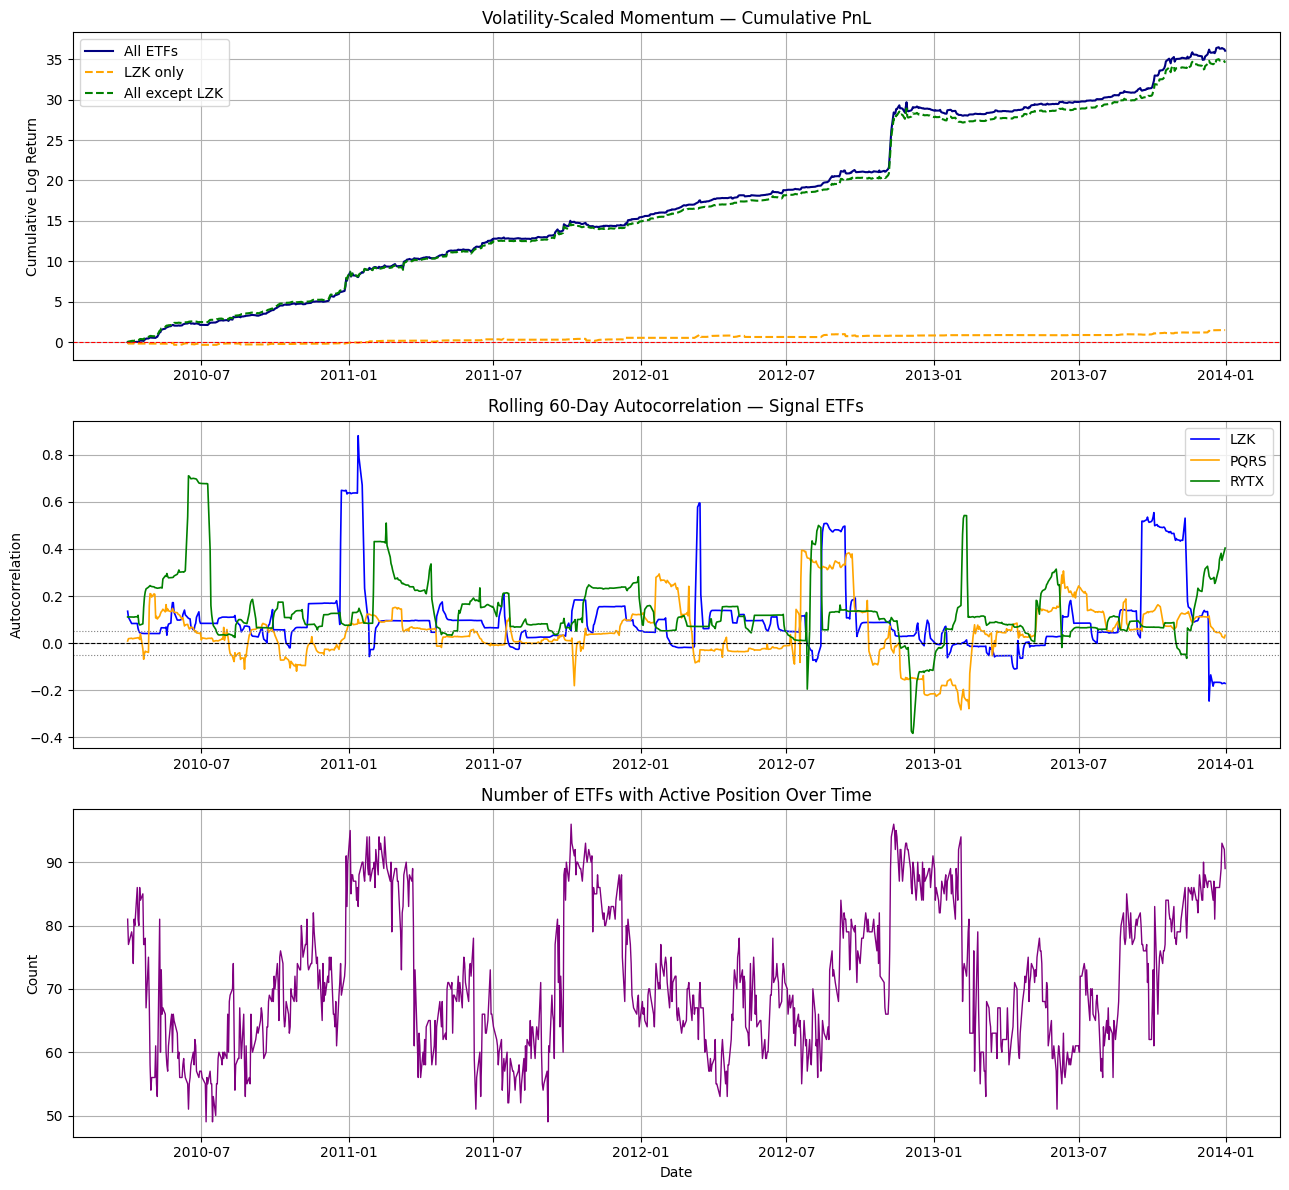

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('df_train.csv', parse_dates=['date'])
df = df.sort_values(['symbol', 'date'])
df['log_return'] = df.groupby('symbol')['close'].transform(
    lambda x: np.log(x / x.shift(1))
)
returns = df.dropna(subset=['log_return']).copy() # Added .copy() to prevent SettingWithCopyWarning

# ── Core idea: rolling autocorrelation as confidence weight ──────────────────
# For each ETF, compute 60-day rolling lag-1 autocorrelation
# This tells us: "how predictable has this ETF been recently?"
# High positive AC → momentum signal → bet on continuation
# High negative AC → mean reversion signal → bet on reversal
# Near zero → no signal → stay flat

returns['rolling_ac'] = returns.groupby('symbol')['log_return'].transform(
    lambda x: x.rolling(60).apply(lambda r: pd.Series(r).autocorr(lag=1), raw=False)
)
returns['prev_return'] = returns.groupby('symbol')['log_return'].transform(
    lambda x: x.shift(1)
)

# ── Position sizing ───────────────────────────────────────────────────────────
# Direction: follow the autocorrelation signal
#   - If rolling_ac > 0: yesterday's return predicts same direction today (momentum)
#   - If rolling_ac < 0: yesterday's return predicts opposite direction (reversion)
# Size: proportional to strength of autocorrelation (stronger signal = bigger bet)

# Threshold: only trade if |rolling_ac| > 0.05 (avoid noise)
AC_THRESHOLD = 0.05
MAX_POSITION = 1.0  # maximum position size per ETF

returns['signal'] = np.sign(returns['rolling_ac']) * np.sign(returns['prev_return'])
returns['position'] = np.where(
    returns['rolling_ac'].abs() > AC_THRESHOLD,
    returns['signal'] * returns['rolling_ac'].abs() * MAX_POSITION,
    0
)
returns = returns.dropna(subset=['rolling_ac'])

# ── PnL calculation ───────────────────────────────────────────────────────────
returns = returns.sort_values(['symbol', 'date'])
returns['prev_position'] = returns.groupby('symbol')['position'].shift(1).fillna(0)
returns['trade_made'] = (
    (returns['position'] - returns['prev_position']).abs() * 0.0005
)
returns['pnl'] = returns['position'] * returns['log_return'] - returns['trade_made']
returns['year'] = returns['date'].dt.year

# ── Results ───────────────────────────────────────────────────────────────────
print("=== PnL by Year ===")
print(returns.groupby('year')['pnl'].sum().round(4))

print("\n=== PnL by ETF (top 15) ===")
print(returns.groupby('symbol')['pnl'].sum().sort_values(ascending=False).head(15).round(4))

print("\n=== PnL by ETF (bottom 10) ===")
print(returns.groupby('symbol')['pnl'].sum().sort_values().head(10).round(4))

print("\nTotal PnL:", returns['pnl'].sum().round(4))
daily_pnl = returns.groupby('date')['pnl'].sum()
sharpe = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252)
print(f"Annualised Sharpe: {sharpe:.4f}")

# ── Sensitivity: test different AC thresholds ─────────────────────────────────
print("\n=== Sensitivity to AC Threshold ===")
for thresh in [0.0, 0.03, 0.05, 0.08, 0.1, 0.15]:
    pos = np.where(
        returns['rolling_ac'].abs() > thresh,
        returns['signal'] * returns['rolling_ac'].abs(),
        0
    )
    pnl = pos * returns['log_return'] - (pos - returns['prev_position']).abs() * 0.0005
    print(f"Threshold {thresh:.2f}: total PnL = {pnl.sum():.4f}")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 12))

# Plot 1: cumulative PnL — overall vs LZK only vs rest
overall_cumPnL = daily_pnl.cumsum()
lzk_cumPnL = returns[returns['symbol']=='LZK'].groupby('date')['pnl'].sum().cumsum()
rest_cumPnL = returns[returns['symbol']!='LZK'].groupby('date')['pnl'].sum().cumsum()

axes[0].plot(overall_cumPnL.index, overall_cumPnL.values, color='navy',
             label='All ETFs', linewidth=1.5)
axes[0].plot(lzk_cumPnL.index, lzk_cumPnL.values, color='orange',
             label='LZK only', linewidth=1.5, linestyle='--')
axes[0].plot(rest_cumPnL.index, rest_cumPnL.values, color='green',
             label='All except LZK', linewidth=1.5, linestyle='--')
axes[0].axhline(0, linestyle='--', color='red', linewidth=0.8)
axes[0].set_title('Volatility-Scaled Momentum — Cumulative PnL')
axes[0].set_ylabel('Cumulative Log Return')
axes[0].legend()
axes[0].grid(True)

# Plot 2: rolling 60-day autocorrelation for LZK, PQRS, RYTX
for etf, color in [('LZK','blue'), ('PQRS','orange'), ('RYTX','green')]:
    ac = returns[returns['symbol']==etf].set_index('date')['rolling_ac']
    axes[1].plot(ac.index, ac.values, label=etf, color=color, linewidth=1.2)
axes[1].axhline(0, linestyle='--', color='black', linewidth=0.8)
axes[1].axhline( 0.05, linestyle=':', color='grey', linewidth=0.8)
axes[1].axhline(-0.05, linestyle=':', color='grey', linewidth=0.8)
axes[1].set_title('Rolling 60-Day Autocorrelation — Signal ETFs')
axes[1].set_ylabel('Autocorrelation')
axes[1].legend()
axes[1].grid(True)

# Plot 3: number of ETFs with active position over time (signal breadth)
returns['has_position'] = (returns['position'] != 0).astype(int)
breadth = returns.groupby('date')['has_position'].sum()
axes[2].plot(breadth.index, breadth.values, color='purple', linewidth=1)
axes[2].set_title('Number of ETFs with Active Position Over Time')
axes[2].set_ylabel('Count')
axes[2].set_xlabel('Date')
axes[2].grid(True)

plt.tight_layout()
plt.savefig('volatility_scaled_momentum.png', dpi=150)
plt.show()

In [40]:
# What drove 2012 outperformance?
returns['year'] = pd.to_datetime(returns['date']).dt.year

# Which ETFs contributed most in 2012 vs other years?
yearly_etf = returns.groupby(['year','symbol'])['pnl'].sum().unstack()
print("Top 10 ETF contributors in 2012:")
print(yearly_etf.loc[2012].sort_values(ascending=False).head(10))

print("\nSame ETFs in other years:")
top_2012 = yearly_etf.loc[2012].sort_values(ascending=False).head(10).index
print(yearly_etf[top_2012].to_string())

Top 10 ETF contributors in 2012:
symbol
QRM     0.316990
PNY     0.292858
LZK     0.286009
MNG     0.277354
KRV     0.274034
TPLF    0.253710
TLWM    0.232405
PWL     0.226882
PQRS    0.221930
AMWD    0.216231
Name: 2012, dtype: float64

Same ETFs in other years:
symbol       QRM       PNY       LZK       MNG       KRV      TPLF      TLWM       PWL      PQRS      AMWD
year                                                                                                      
2010    0.074408  0.053612 -0.106384  0.043335  0.088173  0.050357  0.071335  0.101804  0.070633  0.117698
2011    0.051385  0.047874  0.629028  0.074159  0.061972  0.018738  0.130390  0.076885  0.125842  0.035171
2012    0.316990  0.292858  0.286009  0.277354  0.274034  0.253710  0.232405  0.226882  0.221930  0.216231
2013    0.039381  0.038203  0.671266  0.189358  0.131458  0.033708 -0.003489  0.296521  0.111867  0.104198


ml approach

In [42]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np

df = pd.read_csv('df_train.csv', parse_dates=['date'])
df = df.sort_values(['symbol', 'date'])
df['log_return'] = df.groupby('symbol')['close'].transform(
    lambda x: np.log(x / x.shift(1))
)
returns = df.dropna(subset=['log_return'])

# Focus only on LZK where signal is strongest
lzk = returns[returns['symbol'] == 'LZK'].copy().sort_values('date')

# Build features
lzk['ret_lag1'] = lzk['log_return'].shift(1)
lzk['ret_lag2'] = lzk['log_return'].shift(2)
lzk['ret_lag3'] = lzk['log_return'].shift(3)
lzk['ret_5d']   = lzk['log_return'].rolling(5).sum().shift(1)
lzk['ret_10d']  = lzk['log_return'].rolling(10).sum().shift(1)
lzk['vol_5d']   = lzk['log_return'].rolling(5).std().shift(1)
lzk['range']    = ((lzk['high'] - lzk['low']) / lzk['close']).shift(1) # Corrected calculation using lzk itself
lzk['vol_z']    = (lzk['volume'] - lzk['volume'].rolling(20).mean()) / \
                   lzk['volume'].rolling(20).std()

lzk = lzk.dropna()

feature_cols = ['ret_lag1','ret_lag2','ret_lag3','ret_5d','ret_10d','vol_5d','range','vol_z']
X = lzk[feature_cols].values
y = lzk['log_return'].values  # predict next day return

# CRITICAL: use TimeSeriesSplit — never shuffle time series data
# This mimics the walk-forward evaluation in your assignment
tscv = TimeSeriesSplit(n_splits=4)  # 4 splits ≈ 1 year each

print("=== Walk-Forward LASSO Performance on LZK ===")
fold_results = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    model = LassoCV(cv=3, max_iter=10000)
    model.fit(X_train_sc, y_train)

    # Predicted direction → position
    y_pred = model.predict(X_test_sc)
    position = np.sign(y_pred)
    pnl = position * y_test - 0.0005 * (position != np.roll(position, 1))

    # Compare to simple threshold rule
    simple_pos = np.where(X_test[:, 0] >  0.2,  1,
                 np.where(X_test[:, 0] < -0.2, -1, 0))
    simple_pnl = simple_pos * y_test - 0.0005 * (simple_pos != np.roll(simple_pos, 1))

    print(f"Fold {fold+1}: LASSO PnL={pnl.sum():.4f} | "
          f"Simple rule PnL={simple_pnl.sum():.4f} | "
          f"Non-zero coefs={np.sum(model.coef_ != 0)}")
    fold_results.append({'fold': fold+1, 'lasso': pnl.sum(), 'simple': simple_pnl.sum()})

res = pd.DataFrame(fold_results)
print(f"\nTotal LASSO: {res['lasso'].sum():.4f}")
print(f"Total Simple: {res['simple'].sum():.4f}")
print("\nSelected features (last fold):")
for feat, coef in zip(feature_cols, model.coef_):
    if coef != 0:
        print(f"  {feat}: {coef:.6f}")

=== Walk-Forward LASSO Performance on LZK ===
Fold 1: LASSO PnL=10.4743 | Simple rule PnL=2.9752 | Non-zero coefs=5
Fold 2: LASSO PnL=9.6621 | Simple rule PnL=3.3783 | Non-zero coefs=7
Fold 3: LASSO PnL=5.5274 | Simple rule PnL=1.8018 | Non-zero coefs=7
Fold 4: LASSO PnL=2.1968 | Simple rule PnL=1.0267 | Non-zero coefs=7

Total LASSO: 27.8605
Total Simple: 9.1819

Selected features (last fold):
  ret_lag1: 0.035679
  ret_lag2: 0.019794
  ret_lag3: 0.012154
  ret_10d: -0.022904
  vol_5d: 0.048098
  range: -0.010685
  vol_z: -0.008682


In [44]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

df = pd.read_csv('df_train.csv', parse_dates=['date'])
df = df.sort_values(['symbol', 'date'])
df['log_return'] = df.groupby('symbol')['close'].transform(
    lambda x: np.log(x / x.shift(1))
)
returns = df.dropna(subset=['log_return'])

def build_features(r):
    r = r.copy().sort_values('date')
    r['ret_lag1'] = r['log_return'].shift(1)
    r['ret_lag2'] = r['log_return'].shift(2)
    r['ret_lag3'] = r['log_return'].shift(3)
    r['ret_5d']   = r['log_return'].rolling(5).sum().shift(1)
    r['ret_10d']  = r['log_return'].rolling(10).sum().shift(1)
    r['vol_5d']   = r['log_return'].rolling(5).std().shift(1)
    r['vol_z']    = (r['volume'] - r['volume'].rolling(20).mean()) / \
                     r['volume'].rolling(20).std()
    r['range']    = ((r['high'] - r['low']) / r['close']).shift(1)
    return r.dropna()

feature_cols = ['ret_lag1','ret_lag2','ret_lag3','ret_5d','ret_10d',
                'vol_5d','range','vol_z']

from sklearn.model_selection import TimeSeriesSplit

all_results = {}
for etf in ['LZK', 'PQRS', 'RYTX']:
    r = build_features(returns[returns['symbol'] == etf].copy())
    X = r[feature_cols].values
    y = r['log_return'].values

    tscv = TimeSeriesSplit(n_splits=4)
    fold_pnls_lasso  = []
    fold_pnls_simple = []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        scaler = StandardScaler()
        X_train_sc = scaler.fit_transform(X_train)
        X_test_sc  = scaler.transform(X_test)

        model = LassoCV(cv=3, max_iter=10000)
        model.fit(X_train_sc, y_train)

        # LASSO position
        y_pred   = model.predict(X_test_sc)
        position = np.sign(y_pred)
        pnl_lasso = (position * y_test
                     - 0.0005 * (position != np.roll(position,1))).sum()

        # Simple rule position (threshold on ret_lag1)
        simple_pos = np.where(X_test[:,0] >  0.2,  1,
                     np.where(X_test[:,0] < -0.2, -1, 0))
        pnl_simple = (simple_pos * y_test
                      - 0.0005 * (simple_pos != np.roll(simple_pos,1))).sum()

        fold_pnls_lasso.append(pnl_lasso)
        fold_pnls_simple.append(pnl_simple)

    all_results[etf] = {
        'lasso_total':  sum(fold_pnls_lasso),
        'simple_total': sum(fold_pnls_simple),
        'lasso_folds':  [round(x,3) for x in fold_pnls_lasso],
        'simple_folds': [round(x,3) for x in fold_pnls_simple],
        'coefs': dict(zip(feature_cols, model.coef_))
    }

    print(f"\n=== {etf} ===")
    print(f"LASSO total:  {sum(fold_pnls_lasso):.4f}")
    print(f"Simple total: {sum(fold_pnls_simple):.4f}")
    print(f"LASSO by fold:  {[round(x,3) for x in fold_pnls_lasso]}")
    print(f"Simple by fold: {[round(x,3) for x in fold_pnls_simple]}")
    print("Selected features:")
    for feat, coef in zip(feature_cols, model.coef_):
        if coef != 0:
            print(f"  {feat}: {coef:.6f}")


=== LZK ===
LASSO total:  27.8605
Simple total: 9.1819
LASSO by fold:  [np.float64(10.474), np.float64(9.662), np.float64(5.527), np.float64(2.197)]
Simple by fold: [np.float64(2.975), np.float64(3.378), np.float64(1.802), np.float64(1.027)]
Selected features:
  ret_lag1: 0.035679
  ret_lag2: 0.019794
  ret_lag3: 0.012154
  ret_10d: -0.022904
  vol_5d: 0.048098
  range: -0.010685
  vol_z: -0.008682

=== PQRS ===
LASSO total:  -0.0393
Simple total: 0.2285
LASSO by fold:  [np.float64(-0.002), np.float64(0.69), np.float64(0.151), np.float64(-0.878)]
Simple by fold: [np.float64(-0.036), np.float64(0.105), np.float64(-0.016), np.float64(0.176)]
Selected features:
  vol_5d: -0.001170

=== RYTX ===
LASSO total:  5.9663
Simple total: 0.2704
LASSO by fold:  [np.float64(1.323), np.float64(2.515), np.float64(1.273), np.float64(0.855)]
Simple by fold: [np.float64(0.134), np.float64(0.12), np.float64(-0.004), np.float64(0.021)]
Selected features:
  ret_lag1: 0.009162
  ret_lag2: 0.001929
  ret_lag

In [45]:
# Compare decay RATES between LASSO and simple rule
lasso_folds  = [10.474, 9.662, 5.527, 2.197]
simple_folds = [2.975,  3.378, 1.802, 1.027]

print("=== Decay Analysis ===")
print(f"{'Fold':<8} {'LASSO':>8} {'Simple':>8} {'LASSO/Simple':>14} {'LASSO decay':>12} {'Simple decay':>13}")
for i in range(len(lasso_folds)):
    ratio = lasso_folds[i] / simple_folds[i]
    lasso_decay  = lasso_folds[i] / lasso_folds[0] * 100
    simple_decay = simple_folds[i] / simple_folds[0] * 100
    print(f"Fold {i+1:<3} {lasso_folds[i]:>8.3f} {simple_folds[i]:>8.3f} "
          f"{ratio:>14.2f}x {lasso_decay:>11.1f}% {simple_decay:>12.1f}%")

# Project into test period assuming continued decay
import numpy as np
lasso_decay_rate  = lasso_folds[3]  / lasso_folds[0]   # fold4/fold1
simple_decay_rate = simple_folds[3] / simple_folds[0]

print(f"\nLASSO decay rate fold1→fold4:  {lasso_decay_rate:.3f}")
print(f"Simple decay rate fold1→fold4: {simple_decay_rate:.3f}")

# Project 3 more years
print("\n=== Projected Test Period PnL (3 years) ===")
for year in [1, 2, 3]:
    lasso_proj  = lasso_folds[3]  * (lasso_decay_rate  ** year)
    simple_proj = simple_folds[3] * (simple_decay_rate ** year)
    print(f"Year {year}: LASSO={lasso_proj:.3f}, Simple={simple_proj:.3f}")

=== Decay Analysis ===
Fold        LASSO   Simple   LASSO/Simple  LASSO decay  Simple decay
Fold 1     10.474    2.975           3.52x       100.0%        100.0%
Fold 2      9.662    3.378           2.86x        92.2%        113.5%
Fold 3      5.527    1.802           3.07x        52.8%         60.6%
Fold 4      2.197    1.027           2.14x        21.0%         34.5%

LASSO decay rate fold1→fold4:  0.210
Simple decay rate fold1→fold4: 0.345

=== Projected Test Period PnL (3 years) ===
Year 1: LASSO=0.461, Simple=0.355
Year 2: LASSO=0.097, Simple=0.122
Year 3: LASSO=0.020, Simple=0.042


rytx and 97 etfs strategy

=== PnL by Tier ===
tier
RYTX_LASSO          10.1976
broad_vol_scaled    32.5263
Name: pnl, dtype: float64

=== PnL by Year ===
year
2010    12.1213
2011     8.6877
2012    14.6186
2013     7.2963
Name: pnl, dtype: float64

Total PnL: 42.7239
Sharpe: 3.7691

=== STRATEGY COMPARISON ===
Version                              Total PnL   Sharpe
-------------------------------------------------------
V1: RYTX + 97 ETFs                     42.7239   3.7691
V2: V1 + PQRS                          45.0702   3.9386
V3: V1 + PQRS + LZK (gated)            50.4306   4.3675


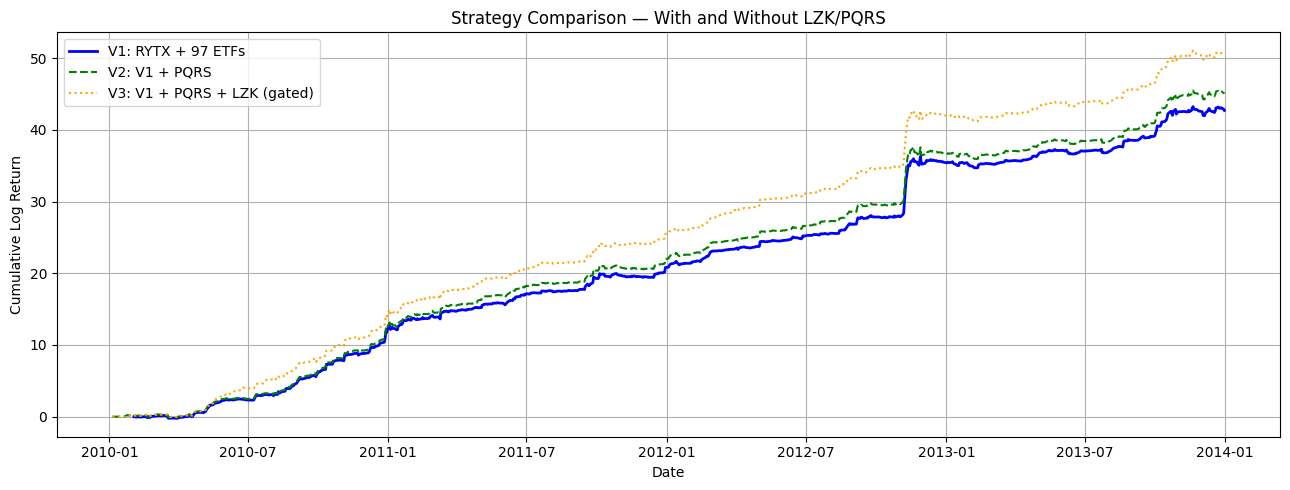

In [48]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('df_train.csv', parse_dates=['date'])
df = df.sort_values(['symbol', 'date'])
df['log_return'] = df.groupby('symbol')['close'].transform(
    lambda x: np.log(x / x.shift(1))
)
returns = df.dropna(subset=['log_return'])

feature_cols = ['ret_lag1','ret_lag2','ret_lag3','ret_5d',
                'ret_10d','vol_5d','range','vol_z']

def build_features(r):
    r = r.copy().sort_values('date')
    r['ret_lag1'] = r['log_return'].shift(1)
    r['ret_lag2'] = r['log_return'].shift(2)
    r['ret_lag3'] = r['log_return'].shift(3)
    r['ret_5d']   = r['log_return'].rolling(5).sum().shift(1)
    r['ret_10d']  = r['log_return'].rolling(10).sum().shift(1)
    r['vol_5d']   = r['log_return'].rolling(5).std().shift(1)
    r['vol_z']    = (r['volume'] - r['volume'].rolling(20).mean()) / \
                     r['volume'].rolling(20).std()
    r['range']    = ((r['high'] - r['low']) / r['close']).shift(1)
    return r.dropna()

# ── Train RYTX LASSO on full training data ────────────────────────────────────
rytx = build_features(returns[returns['symbol'] == 'RYTX'].copy())
scaler_rytx = StandardScaler()
X_rytx = scaler_rytx.fit_transform(rytx[feature_cols].values)
model_rytx = LassoCV(cv=5, max_iter=10000)
model_rytx.fit(X_rytx, rytx['log_return'].values)

all_pnl = []

# ── Tier 1: RYTX — LASSO ─────────────────────────────────────────────────────
r = rytx.copy()
r['position']   = np.sign(model_rytx.predict(X_rytx))
r['prev_pos']   = r['position'].shift(1).fillna(0)
r['trade_made'] = (r['position'] != r['prev_pos']).astype(int)
r['pnl']        = r['position'] * r['log_return'] - 0.0005 * r['trade_made']
r['tier']       = 'RYTX_LASSO'
all_pnl.append(r[['date','symbol','pnl','tier']])

# ── Tier 2: 97 ETFs — volatility scaled momentum ─────────────────────────────
exclude = ['LZK', 'PQRS', 'RYTX']
broad = returns[~returns['symbol'].isin(exclude)].copy()
broad['rolling_ac'] = broad.groupby('symbol')['log_return'].transform(
    lambda x: x.rolling(60).apply(lambda r: pd.Series(r).autocorr(lag=1), raw=False)
)
broad['prev_return'] = broad.groupby('symbol')['log_return'].transform(
    lambda x: x.shift(1)
)
broad = broad.dropna(subset=['rolling_ac', 'prev_return'])
broad['signal']   = np.sign(broad['rolling_ac']) * np.sign(broad['prev_return'])
broad['position'] = np.where(
    broad['rolling_ac'].abs() > 0.05,
    broad['signal'] * broad['rolling_ac'].abs(),
    0
)
broad['prev_pos']   = broad.groupby('symbol')['position'].shift(1).fillna(0)
broad['trade_cost'] = (broad['position'] - broad['prev_pos']).abs() * 0.0005
broad['pnl']        = broad['position'] * broad['log_return'] - broad['trade_cost']
broad['tier']       = 'broad_vol_scaled'
all_pnl.append(broad[['date','symbol','pnl','tier']])

# ── Results ───────────────────────────────────────────────────────────────────
combined = pd.concat(all_pnl)
combined['year'] = pd.to_datetime(combined['date']).dt.year

print("=== PnL by Tier ===")
print(combined.groupby('tier')['pnl'].sum().round(4))

print("\n=== PnL by Year ===")
print(combined.groupby('year')['pnl'].sum().round(4))

print("\nTotal PnL:", combined['pnl'].sum().round(4))
daily = combined.groupby('date')['pnl'].sum()
sharpe = daily.mean() / daily.std() * np.sqrt(252)
print(f"Sharpe: {sharpe:.4f}")

# ── Compare all three versions side by side ───────────────────────────────────
print("\n=== STRATEGY COMPARISON ===")
print(f"{'Version':<35} {'Total PnL':>10} {'Sharpe':>8}")
print("-" * 55)

# Version 1: RYTX + 97 ETFs only (current)
v1_pnl = combined['pnl'].sum()
v1_sharpe = sharpe

# Version 2: Add back PQRS simple rule
pqrs = returns[returns['symbol'] == 'PQRS'].copy().sort_values('date')
pqrs['prev_return'] = pqrs['log_return'].shift(1)
pqrs['position']    = np.where(pqrs['prev_return'] >  0.1,  1,
                      np.where(pqrs['prev_return'] < -0.1, -1, 0))
pqrs['trade_made']  = (pqrs['position'] != pqrs['position'].shift(1).fillna(0)).astype(int)
pqrs['pnl']         = pqrs['position'] * pqrs['log_return'] - 0.0005 * pqrs['trade_made']
v2_total = combined['pnl'].sum() + pqrs['pnl'].sum()
v2_daily = pd.concat([combined, pqrs]).groupby('date')['pnl'].sum()
v2_sharpe = v2_daily.mean() / v2_daily.std() * np.sqrt(252)

# Version 3: Add back LZK gated
lzk = returns[returns['symbol'] == 'LZK'].copy().sort_values('date')
lzk['prev_return'] = lzk['log_return'].shift(1)
lzk['rolling_ac']  = lzk['log_return'].rolling(60).apply(
    lambda x: pd.Series(x).autocorr(lag=1), raw=False
)
lzk = lzk.dropna(subset=['rolling_ac'])
lzk['position'] = np.where(
    (lzk['prev_return'] >  0.2) & (lzk['rolling_ac'] > 0.05),  0.5,
    np.where(
    (lzk['prev_return'] < -0.2) & (lzk['rolling_ac'] < -0.05), -0.5,
    0)
)
lzk['trade_made'] = (lzk['position'] != lzk['position'].shift(1).fillna(0)).astype(int)
lzk['pnl']        = lzk['position'] * lzk['log_return'] - 0.0005 * lzk['trade_made']
v3_total = v2_total + lzk['pnl'].sum()
v3_daily = pd.concat([combined, pqrs, lzk]).groupby('date')['pnl'].sum()
v3_sharpe = v3_daily.mean() / v3_daily.std() * np.sqrt(252)

print(f"{'V1: RYTX + 97 ETFs':<35} {v1_pnl:>10.4f} {v1_sharpe:>8.4f}")
print(f"{'V2: V1 + PQRS':<35} {v2_total:>10.4f} {v2_sharpe:>8.4f}")
print(f"{'V3: V1 + PQRS + LZK (gated)':<35} {v3_total:>10.4f} {v3_sharpe:>8.4f}")

# ── Plot all three versions ───────────────────────────────────────────────────
import matplotlib.pyplot as plt

v1_cum = combined.groupby('date')['pnl'].sum().cumsum()
v2_cum = pd.concat([combined, pqrs]).groupby('date')['pnl'].sum().cumsum()
v3_cum = pd.concat([combined, pqrs, lzk]).groupby('date')['pnl'].sum().cumsum()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(v1_cum.index, v1_cum.values, label='V1: RYTX + 97 ETFs',
        color='blue', linewidth=2)
ax.plot(v2_cum.index, v2_cum.values, label='V2: V1 + PQRS',
        color='green', linewidth=1.5, linestyle='--')
ax.plot(v3_cum.index, v3_cum.values, label='V3: V1 + PQRS + LZK (gated)',
        color='orange', linewidth=1.5, linestyle=':')
ax.set_title('Strategy Comparison — With and Without LZK/PQRS')
ax.set_ylabel('Cumulative Log Return')
ax.set_xlabel('Date')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('strategy_comparison.png', dpi=150)
plt.show()

In [49]:
# Check that LZK and PQRS contributions are stable across years
# not just driven by one lucky year

combined_v3 = pd.concat([combined, pqrs, lzk])
combined_v3['year'] = pd.to_datetime(combined_v3['date']).dt.year

print("=== V3 PnL by Component and Year ===")
pivot = combined_v3.groupby(['tier','year'])['pnl'].sum().round(3).unstack()
print(pivot)

print("\n=== Is LZK gated contribution positive every year? ===")
lzk_yearly = lzk.copy()
lzk_yearly['year'] = pd.to_datetime(lzk_yearly['date']).dt.year
print(lzk_yearly.groupby('year')['pnl'].sum().round(4))

print("\n=== Is PQRS contribution positive every year? ===")
pqrs_yearly = pqrs.copy()
pqrs_yearly['year'] = pd.to_datetime(pqrs_yearly['date']).dt.year
print(pqrs_yearly.groupby('year')['pnl'].sum().round(4))

=== V3 PnL by Component and Year ===
year               2010   2011    2012   2013
tier                                         
RYTX_LASSO        4.703  2.527   2.003  0.965
broad_vol_scaled  7.419  6.160  12.616  6.332

=== Is LZK gated contribution positive every year? ===
year
2010    1.8160
2011    1.6769
2012    1.8240
2013    0.0436
Name: pnl, dtype: float64

=== Is PQRS contribution positive every year? ===
year
2010    0.4459
2011    0.7553
2012    0.0482
2013    1.0970
Name: pnl, dtype: float64


In [50]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
import numpy as np

df = pd.read_csv('df_train.csv', parse_dates=['date'])
df = df.sort_values(['symbol', 'date'])
df['log_return'] = df.groupby('symbol')['close'].transform(
    lambda x: np.log(x / x.shift(1))
)
returns = df.dropna(subset=['log_return'])

# Compute rolling autocorrelation for all ETFs
returns['rolling_ac'] = returns.groupby('symbol')['log_return'].transform(
    lambda x: x.rolling(60).apply(lambda r: pd.Series(r).autocorr(lag=1), raw=False)
)
returns['prev_return'] = returns.groupby('symbol')['log_return'].transform(
    lambda x: x.shift(1)
)

# ── Test: can ML improve on volatility-scaled for the 97 ETFs? ───────────────
exclude = ['LZK', 'PQRS', 'RYTX']
broad = returns[~returns['symbol'].isin(exclude)].copy()

# Build features for each ETF
broad['ret_lag1'] = broad.groupby('symbol')['log_return'].transform(lambda x: x.shift(1))
broad['ret_lag2'] = broad.groupby('symbol')['log_return'].transform(lambda x: x.shift(2))
broad['ret_5d']   = broad.groupby('symbol')['log_return'].transform(
    lambda x: x.rolling(5).sum().shift(1))
broad['ret_10d']  = broad.groupby('symbol')['log_return'].transform(
    lambda x: x.rolling(10).sum().shift(1))
broad['vol_5d']   = broad.groupby('symbol')['log_return'].transform(
    lambda x: x.rolling(5).std().shift(1))
broad['vol_z']    = broad.groupby('symbol')['volume'].transform(
    lambda x: (x - x.rolling(20).mean()) / x.rolling(20).std())
broad['range']    = ((broad['high'] - broad['low']) / broad['close']).shift(1)
broad['ac_lag1']  = broad.groupby('symbol')['rolling_ac'].transform(lambda x: x.shift(1))
broad['ac_change']= broad.groupby('symbol')['rolling_ac'].transform(
    lambda x: x.diff(20).shift(1))

broad = broad.dropna()

feature_cols = ['ret_lag1','ret_lag2','ret_5d','ret_10d',
                'vol_5d','vol_z','range','ac_lag1','ac_change']

# ── Walk-forward test: train on first 3 years, test on year 4 ────────────────
# This is the most honest test — closest to actual out-of-sample conditions
broad['year'] = broad['date'].dt.year
train = broad[broad['year'] <= 2012].copy()
test  = broad[broad['year'] == 2013].copy()

# Train one LASSO model across all 97 ETFs
X_train = train[feature_cols].values
y_train = train['log_return'].values
X_test  = test[feature_cols].values
y_test  = test['log_return'].values

scaler  = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

model = LassoCV(cv=5, max_iter=10000)
model.fit(X_train_sc, y_train)

# ML positions
test = test.copy()
test['ml_pred']     = model.predict(X_test_sc)
test['ml_position'] = np.sign(test['ml_pred'])

# Volatility-scaled positions (benchmark)
test['vs_position'] = np.where(
    test['rolling_ac'].abs() > 0.05,
    np.sign(test['rolling_ac']) * np.sign(test['prev_return']) * test['rolling_ac'].abs(),
    0
)

# PnL comparison
test['ml_pnl'] = test['ml_position'] * test['log_return'] - \
                  0.0005 * (test['ml_position'] != test.groupby('symbol')['ml_position'].shift(1).fillna(0))
test['vs_pnl'] = test['vs_position'] * test['log_return'] - \
                  0.0005 * (test['vs_position'] - test.groupby('symbol')['vs_position'].shift(1).fillna(0)).abs()

print("=== 2013 Out-of-Sample Comparison (97 ETFs) ===")
print(f"ML (LASSO) PnL:              {test['ml_pnl'].sum():.4f}")
print(f"Volatility-scaled PnL:       {test['vs_pnl'].sum():.4f}")

print("\n=== Selected Features ===")
for feat, coef in zip(feature_cols, model.coef_):
    if coef != 0:
        print(f"  {feat}: {coef:.6f}")

print("\n=== Non-zero coefficients: ===", (model.coef_ != 0).sum())

# Also test on earlier years to check consistency
print("\n=== Year-by-year walk-forward ===")
results = []
for test_year in [2011, 2012, 2013]:
    train_y = broad[broad['year'] < test_year].copy()
    test_y  = broad[broad['year'] == test_year].copy()

    X_tr = train_y[feature_cols].values
    y_tr = train_y['log_return'].values
    X_te = test_y[feature_cols].values
    y_te = test_y['log_return'].values

    sc = StandardScaler()
    model_y = LassoCV(cv=5, max_iter=10000)
    model_y.fit(sc.fit_transform(X_tr), y_tr)

    ml_pos = np.sign(model_y.predict(sc.transform(X_te)))
    ml_pnl = (ml_pos * y_te - 0.0005).sum()

    vs_pos = np.where(
        test_y['rolling_ac'].abs() > 0.05,
        np.sign(test_y['rolling_ac']) * np.sign(test_y['prev_return']) * test_y['rolling_ac'].abs(),
        0
    )
    vs_pnl = (vs_pos * y_te - 0.0005 * (vs_pos != 0)).sum()

    results.append({
        'test_year': test_year,
        'ml_pnl': round(ml_pnl, 4),
        'vs_pnl': round(vs_pnl, 4),
        'ml_wins': ml_pnl > vs_pnl
    })
    print(f"Year {test_year}: ML={ml_pnl:.4f} | Vol-scaled={vs_pnl:.4f} | "
          f"ML wins: {ml_pnl > vs_pnl}")

res = pd.DataFrame(results)
print(f"\nML wins {res['ml_wins'].sum()} out of {len(res)} years")
print(f"Total ML:          {res['ml_pnl'].sum():.4f}")
print(f"Total Vol-scaled:  {res['vs_pnl'].sum():.4f}")

/tmp/ipykernel_683/1970306475.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  returns['rolling_ac'] = returns.groupby('symbol')['log_return'].transform(
/tmp/ipykernel_683/1970306475.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  returns['prev_return'] = returns.groupby('symbol')['log_return'].transform(


=== 2013 Out-of-Sample Comparison (97 ETFs) ===
ML (LASSO) PnL:              2.5889
Volatility-scaled PnL:       6.3269

=== Selected Features ===
  ret_lag1: 0.000142
  ret_lag2: 0.001123
  ret_5d: -0.002943
  ret_10d: 0.000587
  vol_5d: -0.000675
  vol_z: -0.001551
  range: 0.000139
  ac_lag1: -0.000448
  ac_change: -0.000181

=== Non-zero coefficients: === 9

=== Year-by-year walk-forward ===
Year 2011: ML=8.6404 | Vol-scaled=-1.4516 | ML wins: True
Year 2012: ML=-38.1567 | Vol-scaled=5.4557 | ML wins: False
Year 2013: ML=-5.5201 | Vol-scaled=-0.9364 | ML wins: False

ML wins 1 out of 3 years
Total ML:          -35.0364
Total Vol-scaled:  3.0677
